<a href="https://colab.research.google.com/github/Yosh004/TelcoCustomerChurn/blob/main/TelcoCustomerChurnCW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#adding styles for the plots
sns.set_style('whitegrid')
try:
    df = pd.read_csv('/content/drive/MyDrive/TelcoCustomerChurn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: The CSV file was not found. Please check the file path.")

Dataset loaded successfully.


Task 1 - Exploratory Data Anaysis(EDA)

In [16]:
#Initial inspection of the Telco dataset
print("Initial inpsection of the dataSet")
print("\nFirst 5 rows of the TelcoDataSet:")
print(df.head())
print("\nData Structure and Types:")
df.info()
print(f"\nNumber of duplicated rows: {df.duplicated().sum()}")
print("\nStatistical Summary of Numerical Columns:")
print(df.describe())
df.drop('customerID', axis=1, inplace=True)
print("\n'customerID' column dropped.")#removing the customerID column as it is unique

Initial inpsection of the dataSet

First 5 rows of the TelcoDataSet:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               

In [17]:
#Data cleaning and handling missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')# Convert 'TotalCharges' to numeric
missing_values = df.isnull().sum()# Identify the missing values
print("\nMissing values per column (after TotalCharges fix):")
print(missing_values[missing_values > 0])
df.dropna(inplace=True)#remove missing values (Only small amount available)
print(f"\nRemaining rows after dropping Not a number values: {df.shape[0]}")


Missing values per column (after TotalCharges fix):
TotalCharges    11
dtype: int64

Remaining rows after dropping Not a number values: 7032



 Target Variable Analysis 

Churn Counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Percentage: 
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64%


/tmp/ipython-input-1373695277.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='pastel')


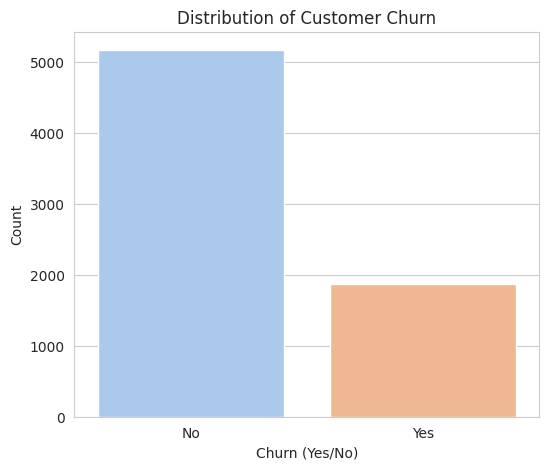

In [18]:
print("\n Target Variable Analysis ")
churn_counts = df['Churn'].value_counts()
churn_ratio = df['Churn'].value_counts(normalize=True) * 100
print("\nChurn Counts:")
print(churn_counts)
print(f"\nChurn Percentage: \n{churn_ratio.round(2)}%")
# Visualize the Churn distribution
plt.figure(figsize=(6, 5))
sns.countplot(x='Churn', data=df, palette='pastel')
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn (Yes/No)')
plt.ylabel('Count')
plt.show()


 Categorical Feature Analysis vs. Churn 


/tmp/ipython-input-1135759278.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data=df.replace({'Churn': {'Yes': 1, 'No': 0}}), # Temporarily replace 'Yes' with 1 and 'No' with 0
/tmp/ipython-input-1135759278.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipython-input-1135759278.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


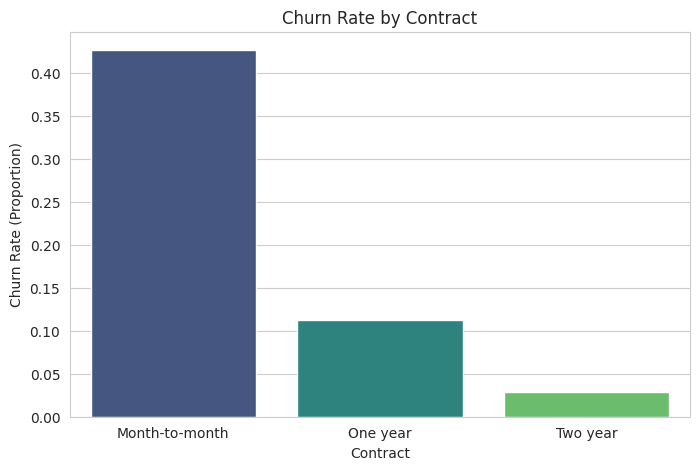

/tmp/ipython-input-1135759278.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data=df.replace({'Churn': {'Yes': 1, 'No': 0}}), # Temporarily replace 'Yes' with 1 and 'No' with 0
/tmp/ipython-input-1135759278.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipython-input-1135759278.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


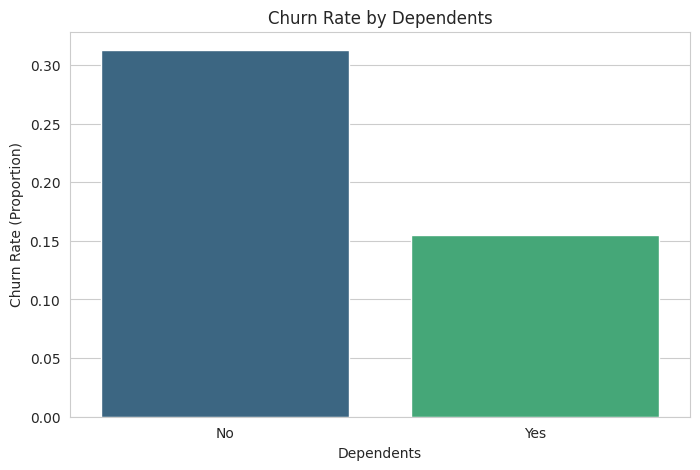

/tmp/ipython-input-1135759278.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data=df.replace({'Churn': {'Yes': 1, 'No': 0}}), # Temporarily replace 'Yes' with 1 and 'No' with 0
/tmp/ipython-input-1135759278.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipython-input-1135759278.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


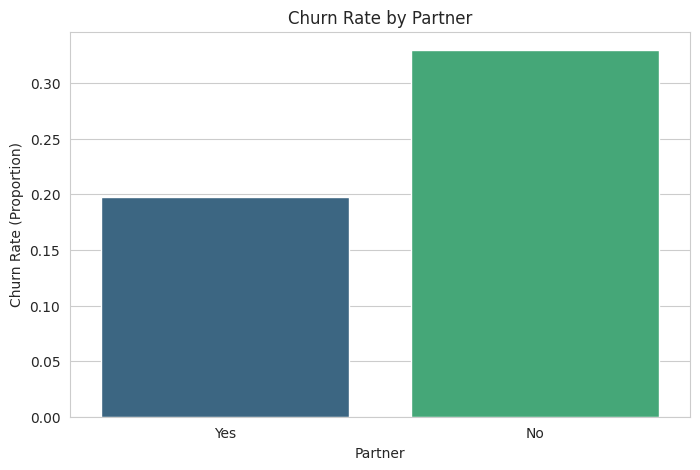

/tmp/ipython-input-1135759278.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data=df.replace({'Churn': {'Yes': 1, 'No': 0}}), # Temporarily replace 'Yes' with 1 and 'No' with 0
/tmp/ipython-input-1135759278.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipython-input-1135759278.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


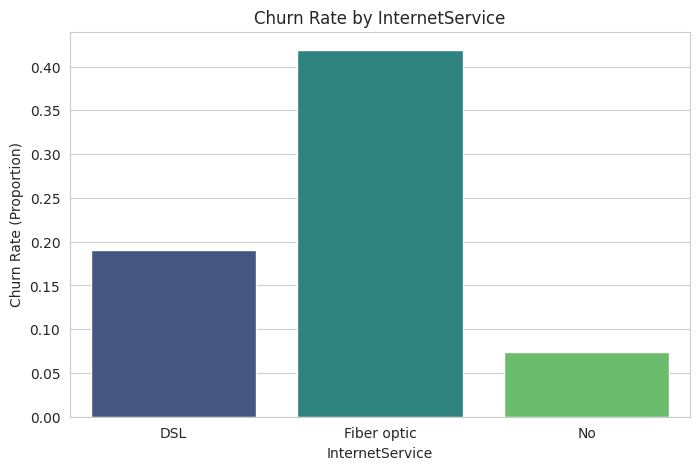

/tmp/ipython-input-1135759278.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data=df.replace({'Churn': {'Yes': 1, 'No': 0}}), # Temporarily replace 'Yes' with 1 and 'No' with 0
/tmp/ipython-input-1135759278.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipython-input-1135759278.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


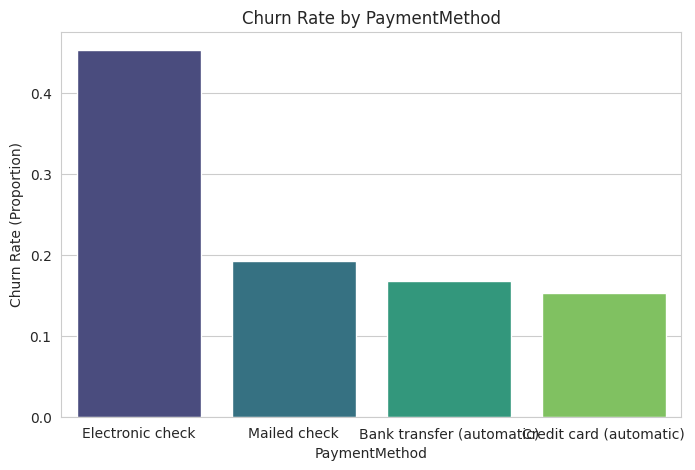


## Numerical Feature Analysis vs. Churn ##


/tmp/ipython-input-1135759278.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=column, data=df, palette='Set2')


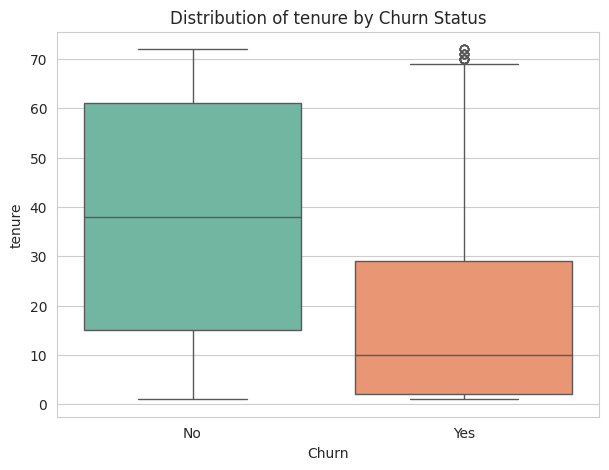

/tmp/ipython-input-1135759278.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=column, data=df, palette='Set2')


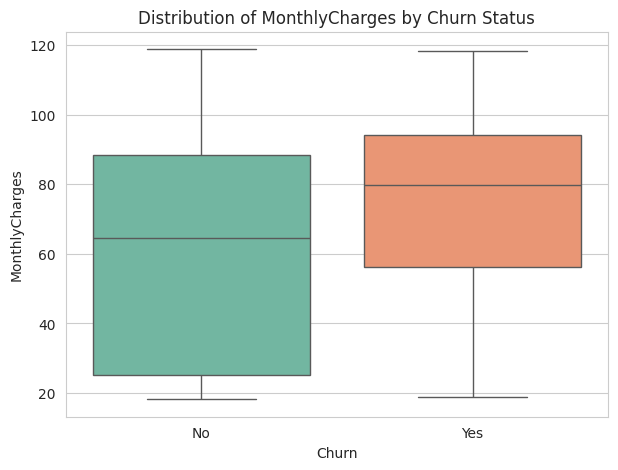


 Numerical Correlation Analysis 


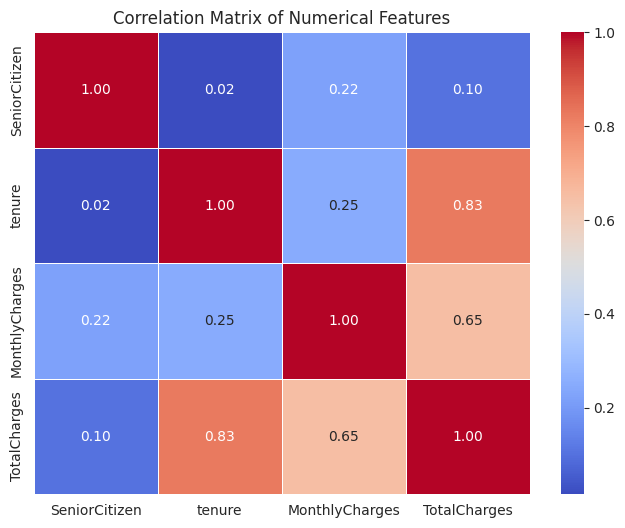

In [19]:
#Exploratory Data Analysis (Feature vs. Churn)
#Categorical Features Analysis
print("\n Categorical Feature Analysis vs. Churn ")
categorical_features = ['Contract', 'Dependents', 'Partner', 'InternetService', 'PaymentMethod']
def plot_categorical_churn(df, column):
    plt.figure(figsize=(8, 5))
    # Use a normalized bar plot to show the percentage of churn within each category
    sns.barplot(
        x=column,
        y='Churn',
        data=df.replace({'Churn': {'Yes': 1, 'No': 0}}), # Temporarily replace 'Yes' with 1 and 'No' with 0
        estimator=np.mean, # Calculates the mean of 'Churn' (which is the Churn rate)
        ci=None,
        palette='viridis'
    )
    plt.title(f'Churn Rate by {column}')
    plt.ylabel('Churn Rate (Proportion)')
    plt.show()

for feature in categorical_features:
    plot_categorical_churn(df, feature)

  #Numerical Features Analysis
print("\n## Numerical Feature Analysis vs. Churn ##")
numerical_features = ['tenure', 'MonthlyCharges']
def plot_numerical_churn(df, column):
    plt.figure(figsize=(7, 5))
    sns.boxplot(x='Churn', y=column, data=df, palette='Set2')
    plt.title(f'Distribution of {column} by Churn Status')
    plt.show()

for feature in numerical_features:
      plot_numerical_churn(df,feature)

#Numerical Correlation Analysis
print("\n Numerical Correlation Analysis ")
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix=numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(
correlation_matrix,
annot=True,
fmt=".2f",
cmap='coolwarm',
linewidths=0.5
)
plt.title('Correlation Matrix of Numerical Features')
plt.show()


Task 2 - Data Cleaning, Preprocessing and classification using Neural Network and Decision Tree models

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score

#Load and clean data
try:
  df=pd.read_csv('/content/drive/MyDrive/TelcoCustomerChurn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
  print("Dataset loaded successfully.")
except FileNotFoundError:
  print("Error: The CSV file was not found. Please check the file path.")
  exit()
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df.dropna(inplace=True)
print(f"Data cleaned. Remaining rows: {df.shape[0]}")

#Feature seperation and target encoding
X=df.drop('Churn', axis=1)
y=df['Churn']
le=LabelEncoder()
y=le.fit_transform(y)
numerical_features=X.select_dtypes(include=['int64', 'float64']).columns
categorical_features=X.select_dtypes(include=['object']).columns

#Preprocessing pipeline
numerical_transformer=StandardScaler()
categorical_transformer=OneHotEncoder(handle_unknown='ignore',drop='first')
preprocessor=ColumnTransformer(
    transformers=[
        ('num',numerical_transformer,numerical_features),
        ('cat',categorical_transformer,categorical_features)
])
X_processed=preprocessor.fit_transform(X)
print(f"Data preprocessed. Shape: {X_processed.shape}")

#Train test split
X_train,X_test,y_train,y_test=train_test_split(X_processed,y,test_size=0.2,random_state=42,stratify=y)
print(f"Data split into Training ({X_train.shape[0]}rows)and testing ({X_test.shape[0]}rows)")



Dataset loaded successfully.
Data cleaned. Remaining rows: 7032
Data preprocessed. Shape: (7032, 7061)
Data split into Training (5625rows)and testing (1407rows)


In [21]:
#Decision Tree model implementation and hyperparamter tuning
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve

print("Decision Tree Model Implementation")
param_grid = {
    'max_depth': [3, 5, 7, 10, None], # None means unlimited depth
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
dt_model = DecisionTreeClassifier(random_state=42)
grid_search_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    scoring='f1',
    cv=5, # 5-fold cross-validation
    verbose=0,
    n_jobs=-1 # Use all processors
)
grid_search_dt.fit(X_train, y_train)
best_dt_model = grid_search_dt.best_estimator_
y_pred_dt = best_dt_model.predict(X_test)
y_proba_dt = best_dt_model.predict_proba(X_test)[:, 1]
print(f"Best Decision Tree Hyperparameters: {grid_search_dt.best_params_}")
print("Decision Tree Evaluation on Test Set")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_dt):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

train_sizes, train_scores, val_scores = learning_curve(
    dt_model,              # your trained Decision Tree variable
    X_train, y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)


Decision Tree Model Implementation
Best Decision Tree Hyperparameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Decision Tree Evaluation on Test Set
Accuracy: 0.7520
ROC AUC Score: 0.7818
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.80      0.83      1033
           1       0.53      0.61      0.57       374

    accuracy                           0.75      1407
   macro avg       0.69      0.71      0.70      1407
weighted avg       0.77      0.75      0.76      1407



In [22]:
#MLPClassifier for Neural Network implementation
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report,roc_auc_score

print("MLPClassifier for Neural Network implementation")
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'max_iter': [100]
}
mlp_model = MLPClassifier(random_state=42,early_stopping=True)
grid_search_mlp = GridSearchCV(
    estimator=mlp_model,
    param_grid=param_grid_mlp,
    scoring='f1',
    cv=3, # Using 3-fold cross-validation
    verbose=0,
    n_jobs=-1 # Use all available processors
)
print("Starting MLPClassifier Grid Search")
grid_search_mlp.fit(X_train, y_train)
best_mlp_model = grid_search_mlp.best_estimator_
y_pred_mlp = best_mlp_model.predict(X_test)
y_proba_mlp = best_mlp_model.predict_proba(X_test)[:, 1]
print(f"Best MLP Hyperparameters: {grid_search_mlp.best_params_}")
print("MLPClassifier Evaluation on Test Set")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_mlp):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_mlp))

MLPClassifier for Neural Network implementation
Starting MLPClassifier Grid Search
Best MLP Hyperparameters: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (100,), 'max_iter': 100}
MLPClassifier Evaluation on Test Set
Accuracy: 0.7953
ROC AUC Score: 0.8289
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.63      0.56      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



Model Performance table:
                Accuracy  F1-Score  AUC-ROC
Model                                      
Decision Tree     0.7520    0.5675   0.7818
MLP Classifier    0.7953    0.5909   0.8289


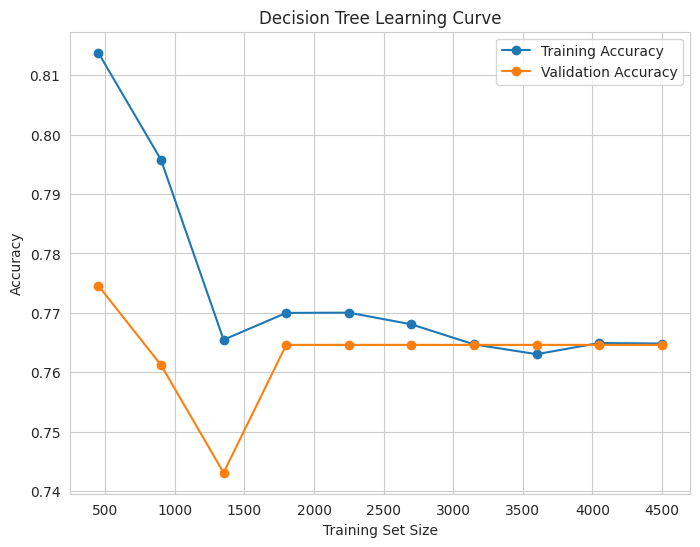

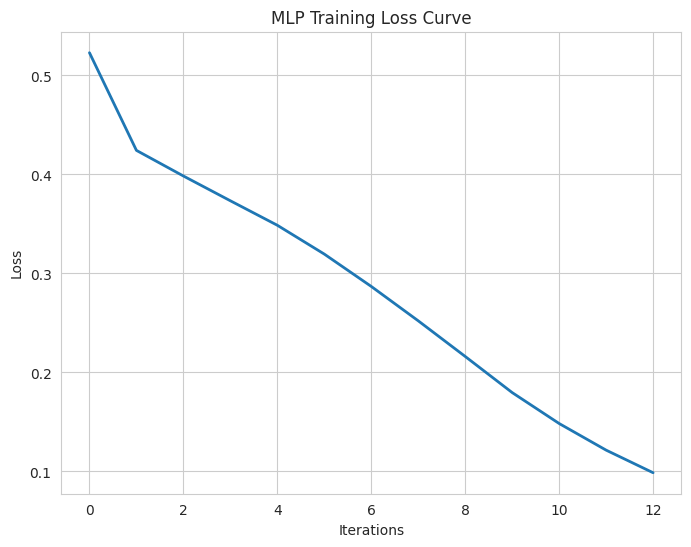

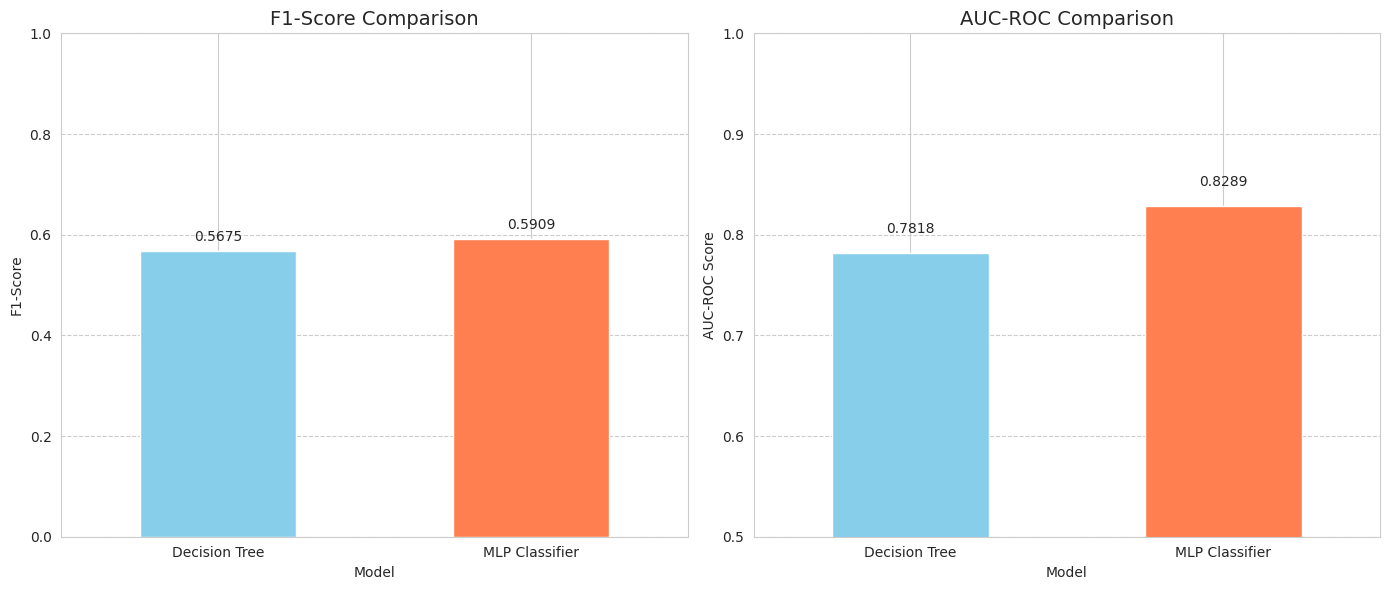

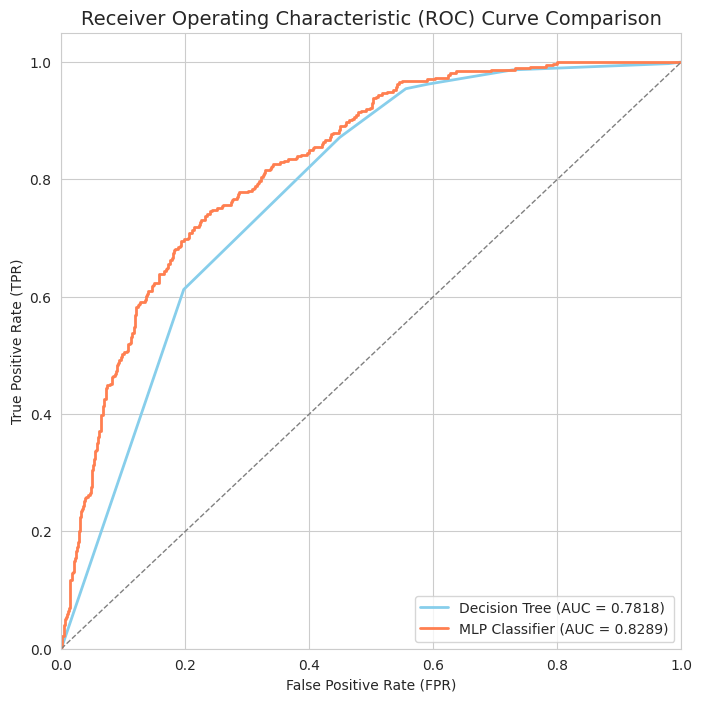

Final Model Selection 
The best overall model is the **MLP Classifier**.
It achieved the highest AUC-ROC (0.8289) and F1-Score (0.5909).


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,f1_score,roc_auc_score,auc, roc_curve
from sklearn.model_selection import GridSearchCV, learning_curve, train_test_split

#Consolidate Metrics
metrics = {
    'Model': ['Decision Tree', 'MLP Classifier'],
    'Accuracy': [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_mlp)],
    'F1-Score': [f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_mlp)],
    'AUC-ROC': [roc_auc_score(y_test, y_proba_dt), roc_auc_score(y_test, y_proba_mlp)]
}
metrics_df = pd.DataFrame(metrics).set_index('Model')
print("Model Performance table:")
print(metrics_df.round(4))

# Learning Curve (Decision Tree)
train_sizes, train_scores, val_scores = learning_curve(
    best_dt_model,
    X_train, y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', label="Training Accuracy")
plt.plot(train_sizes, val_mean, 'o-', label="Validation Accuracy")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Decision Tree Learning Curve")
plt.legend()
plt.grid(True)
plt.savefig("DecisionTree_LearningCurve.png")
plt.show()


# ANN / MLP Loss Curve
plt.figure(figsize=(8, 6))
plt.plot(best_mlp_model.loss_curve_, lw=2)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve")
plt.grid(True)
plt.savefig("MLP_Training_Loss_Curve.png")
plt.show()

#Plot Metrics(F1-Score and AUC-ROC)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
metrics_df['F1-Score'].plot(kind='bar', ax=ax[0], color=['skyblue', 'coral'])
ax[0].set_title('F1-Score Comparison', fontsize=14)
ax[0].set_ylabel('F1-Score')
ax[0].set_ylim(0, 1)
ax[0].tick_params(axis='x', rotation=0)
ax[0].grid(axis='y', linestyle='--')
for i, v in enumerate(metrics_df['F1-Score']):
    ax[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=10)
metrics_df['AUC-ROC'].plot(kind='bar', ax=ax[1], color=['skyblue', 'coral'])
ax[1].set_title('AUC-ROC Comparison', fontsize=14)
ax[1].set_ylabel('AUC-ROC Score')
ax[1].set_ylim(0.5, 1) # ROC scores usually start from 0.5 (random guess)
ax[1].tick_params(axis='x', rotation=0)
ax[1].grid(axis='y', linestyle='--')
for i, v in enumerate(metrics_df['AUC-ROC']):
    ax[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('Model_Metrics_Comparison.png')
plt.show()

#Plot roc curve comparison
plt.figure(figsize=(8, 8))
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)
roc_auc_mlp = auc(fpr_mlp, tpr_mlp)
plt.plot(fpr_dt, tpr_dt, color='skyblue', lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.4f})')
plt.plot(fpr_mlp, tpr_mlp, color='coral', lw=2, label=f'MLP Classifier (AUC = {roc_auc_mlp:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('ROC_Curve_Comparison.png')
plt.show()

#Identifying and displaying the best model
best_auc_model = metrics_df['AUC-ROC'].idxmax()
best_auc_score = metrics_df['AUC-ROC'].max()
best_f1_model = metrics_df['F1-Score'].idxmax()
best_f1_score = metrics_df['F1-Score'].max()


print("Final Model Selection ")
if best_auc_model == best_f1_model:
    print(f"The best overall model is the **{best_auc_model}**.")
    print(f"It achieved the highest AUC-ROC ({best_auc_score:.4f}) and F1-Score ({best_f1_score:.4f}).")
else:
    print(f"The models perform differently based on metrics:")
    print(f" - Best AUC-ROC (overall ranking ability): {best_auc_model} ({best_auc_score:.4f})")
    print(f" - Best F1-Score (best for imbalanced classes): {best_f1_model} ({best_f1_score:.4f})")
    print(f"For Churn Prediction (an imbalanced problem), the **{best_f1_model}** is generally considered the most accurate model.")


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [26]:
print("\n--- Information about the processed dataset ---")
print(f"Shape of the full preprocessed dataset (X_processed): {X_processed.shape}")#total number of samples and total number of features
print(f"Shape of the training features (X_train): {X_train.shape}")
print(f"Shape of the testing features (X_test): {X_test.shape}")
print(f"Shape of the training target (y_train): {y_train.shape}")
print(f"Shape of the testing target (y_test): {y_test.shape}")



--- Information about the processed dataset ---
Shape of the full preprocessed dataset (X_processed): (7032, 7061)
Shape of the training features (X_train): (5625, 7061)
Shape of the testing features (X_test): (1407, 7061)
Shape of the training target (y_train): (5625,)
Shape of the testing target (y_test): (1407,)
